Dataset Shape: (2000, 9)
   url_length  dots  hyphens  special_characters  https  subdomains  \
0         107     5        4                   1      1           2   
1          44     3        0                   1      1           2   
2         142     5        2                   7      0           4   
3          30     3        0                   2      1           0   
4          63     5        3                   5      1           5   

   ip_address  suspicious_words  label  
0           1                 1      1  
1           0                 0      0  
2           1                 0      1  
3           0                 0      0  
4           0                 0      1  
Training Data: (1600, 8)
Testing Data : (400, 8)

Random Forest Accuracy: 100.0 %

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       200
           1       1.00      1.00      1.00       200

    accuracy                    

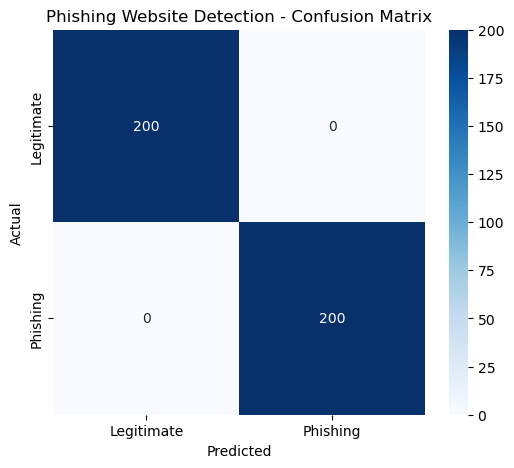

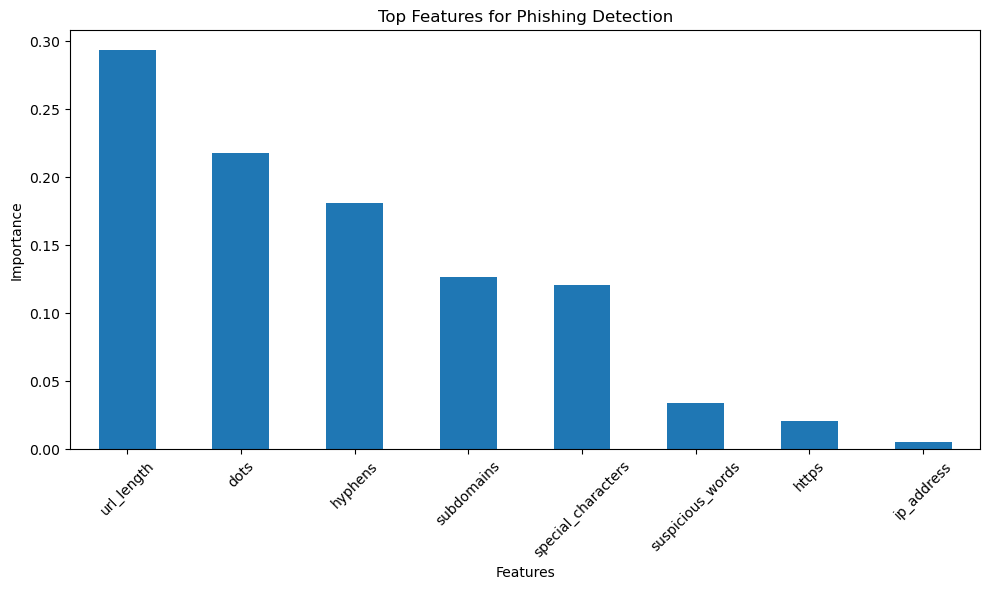

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# --------------------------------------------------
# 1. Load Dataset
# --------------------------------------------------

df = pd.read_csv("Documents/phishing.csv")

print("Dataset Shape:", df.shape)
print(df.head())

# --------------------------------------------------
# 2. Prepare Features and Target
# --------------------------------------------------

X = df.drop("label", axis=1)
y = df["label"]

# --------------------------------------------------
# 3. Split Dataset
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

# --------------------------------------------------
# 4. Create Random Forest Model
# --------------------------------------------------

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

# --------------------------------------------------
# 5. Train Model
# --------------------------------------------------

model.fit(X_train, y_train)

# --------------------------------------------------
# 6. Prediction
# --------------------------------------------------

y_pred = model.predict(X_test)

# --------------------------------------------------
# 7. Model Evaluation
# --------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\nRandom Forest Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# --------------------------------------------------
# 8. Confusion Matrix
# --------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Phishing"],
    yticklabels=["Legitimate", "Phishing"]
)

plt.title("Phishing Website Detection - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# --------------------------------------------------
# 9. Feature Importance
# --------------------------------------------------

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importance.head(15).plot(kind="bar")

plt.title("Top Features for Phishing Detection")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [2]:
new_data = [[
    75,    # URL length
    5,     # dots
    3,     # hyphens
    2,     # special characters
    1,     # HTTPS
    4,     # subdomains
    0,     # IP address
    1      # suspicious words
]]

prediction = model.predict(new_data)

if prediction[0] == 1:
    print("⚠️ Phishing Website")
else:
    print("✅ Legitimate Website")

⚠️ Phishing Website


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
